# ⚡ Electric Machine Failure Risk Prediction System

This notebook demonstrates the end-to-end pipeline for predicting failure risk in electric machines using real-time sensor data. The system uses **XGBoost** with advanced feature engineering, including lag features and robust scaling.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import shap
import matplotlib.pyplot as plt
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Load and Preprocess Data

In [2]:
df = pd.read_excel('equipment_monitoring_1000.xlsx', header=1)
df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df = df.sort_values('Timestamp').reset_index(drop=True)

sensor_cols = ['Actual Voltage (V)', 'Actual Current (A)', 'Temperature (°C)', 'Vibration (mm/s)', 'Speed (RPM)', 'Load %']
for col in sensor_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    df = df[abs(z_scores) < 3]
df.head()

,Date,Time,Actual Voltage (V),Actual Current (A),Temperature (°C),Vibration (mm/s),Speed (RPM),Load %,Failure Risk %,Status,Timestamp
0,2025-01-01,08:00:00,225.6,14.86,60.0,3.14,1517,60.2,61.6,⚠️ Warning,2025-01-01 08:00:00
1,2025-01-01,14:00:00,229.4,11.26,59.0,3.95,1418,54.5,39.1,✅ Safe,2025-01-01 14:00:00
2,2025-01-01,20:00:00,231.9,13.55,48.7,0.66,1501,87.1,33.7,✅ Safe,2025-01-01 20:00:00
3,2025-01-02,02:00:00,219.8,13.92,77.8,3.84,1492,83.0,79.1,🔴 High Risk,2025-01-02 02:00:00
4,2025-01-02,08:00:00,218.6,9.95,76.1,2.19,1472,78.4,51.8,⚠️ Warning,2025-01-02 08:00:00


## 3. Advanced Feature Engineering
- **Physical Deviations**: Deviation from rated specs.
- **Rolling Features**: Smoothing and Trend detection.
- **Lag Features**: Capturing temporal degradation patterns.

In [3]:
specs = {'Rated_Voltage': 230, 'Rated_Current': 11.5, 'Max_Winding_Temp': 155}
df['Voltage_Deviation'] = abs(df['Actual Voltage (V)'] - specs['Rated_Voltage'])
df['Temp_Margin'] = specs['Max_Winding_Temp'] - df['Temperature (°C)']
df['Load_Stress'] = (df['Load %'] / 100) * (df['Actual Current (A)'] / specs['Rated_Current'])
df['Vibration_Smooth'] = df['Vibration (mm/s)'].rolling(window=5, min_periods=1).mean()
df['Temp_Smooth'] = df['Temperature (°C)'].rolling(window=5, min_periods=1).mean()
df['Vibration_Trend'] = df['Vibration (mm/s)'].diff().rolling(window=5, min_periods=1).mean()

for col in sensor_cols:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag3'] = df[col].shift(3)
    df[f'{col}_lag5'] = df[col].shift(5)

df = df.fillna(method='bfill').fillna(method='ffill')

lag_features = [f'{col}_lag{i}' for col in sensor_cols for i in [1, 3, 5]]
features = sensor_cols + ['Voltage_Deviation', 'Temp_Margin', 'Load_Stress', 'Vibration_Smooth', 'Temp_Smooth', 'Vibration_Trend'] + lag_features

X = df[features]
y = df['Failure Risk %'].clip(0, 100)

## 4. Model Training & Cross-Validation

In [4]:
tscv = TimeSeriesSplit(n_splits=5)
train_indices, test_indices = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {'n_estimators': [100, 300, 500], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1]}
search = RandomizedSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42), param_grid, cv=tscv, n_iter=5, random_state=42)
search.fit(X_train_scaled, y_train)
model = search.best_estimator_
print(f"Best Params: {search.best_params_}")

Best Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


## 5. Evaluation & Explainability

MAE: 2.6083
R2: 0.9799


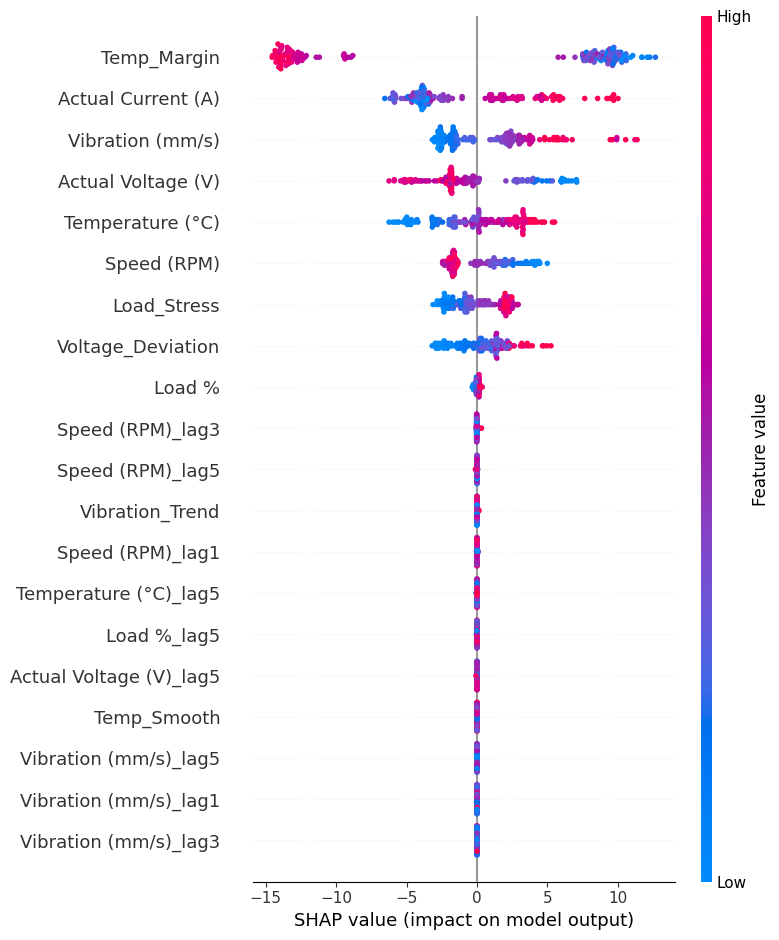

In [5]:
y_pred = np.clip(model.predict(X_test_scaled), 0, 100)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=features)